In [1]:
!pip install torch torchvision torchaudio
!pip install pytorch-lightning
!pip install scikit-learn

   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/122.1 MB ? eta -:--:--
    --------------------------------------- 1.6/122.1 MB 3.9 MB/s eta 0:00:31
    --------------------------------------- 2.4/122.1 MB 3.8 MB/s eta 0:00:32
    --------------------------------------- 2.9/122.1 MB 3.4 MB/s eta 0:00:36
   - -------------------------------------- 3.4/122.1 MB 3.2 MB/s eta 0:00:37
   - -------------------------------------- 3.7/122.1 MB 2.9 MB/s eta 0:00:41
   - -------------------------------------- 3.9/122.1 MB 2.7 MB/s eta 0:00:44
   - -------------------------------------- 4.5/122.1 MB 2.6 MB/s eta 0:00:47
   - -------------------------------------- 5.0/122.1 MB 2.5 MB/s eta 0:00:48
   - -------------------------------------- 5.2/122.1 MB 2.4 MB/s eta 0:00:49
   - -------------------------------------- 5.8/122.1 MB 2.4 MB/s eta 0:00:49
   -- ------------------------------------- 6.3/122.1 MB 2.4 MB/s eta 0:00:49


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import pytorch_lightning as pl

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
df1 = pd.read_csv("Year_2009_2010_Cleaned.csv")
df2 = pd.read_csv("Year_2010_2011_Cleaned.csv")

df = pd.concat([df1, df2], ignore_index=True)

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [4]:
daily_sales = (df.groupby(df["InvoiceDate"].dt.date)["Quantity"].sum().reset_index())

daily_sales.columns = ["Date", "Demand"]

daily_sales["Date"] = pd.to_datetime(daily_sales["Date"])

daily_sales.head()

,Date,Demand
0,2009-12-01,24403
1,2009-12-02,29751
2,2009-12-03,48032
3,2009-12-04,20057
4,2009-12-05,5119


In [5]:
scaler = MinMaxScaler()

daily_sales["Scaled"] = scaler.fit_transform(daily_sales[["Demand"]])

daily_sales.head()

,Date,Demand,Scaled
0,2009-12-01,24403,0.181226
1,2009-12-02,29751,0.224581
2,2009-12-03,48032,0.372781
3,2009-12-04,20057,0.145994
4,2009-12-05,5119,0.024896


In [6]:
sequence_length = 30

X = []
y = []

values = daily_sales["Scaled"].values

for i in range(len(values) - sequence_length):
    X.append(values[i:i+sequence_length])
    y.append(values[i+sequence_length])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(574, 30)
(574,)


In [7]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [8]:
class SalesDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [9]:
train_loader = DataLoader(
    SalesDataset(X_train, y_train),
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    SalesDataset(X_test, y_test),
    batch_size=32,
    shuffle=False
)

In [10]:
class LSTMForecast(pl.LightningModule):

    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=64,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Linear(64, 1)

        self.loss_fn = nn.MSELoss()

    def forward(self, x):

        output, _ = self.lstm(x)

        output = output[:, -1, :]

        return self.fc(output)

    def training_step(self, batch, batch_idx):

        x, y = batch

        pred = self(x).squeeze()

        loss = self.loss_fn(pred, y)

        self.log("train_loss", loss)

        return loss

    def configure_optimizers(self):

        return torch.optim.Adam(
            self.parameters(),
            lr=0.001
        )

In [11]:
model = LSTMForecast()

trainer = pl.Trainer(
    max_epochs=20,
    accelerator="auto",
    devices=1
)

trainer.fit(model, train_loader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
C:\Users\HOME\anaconda3\Lib\site-packages\pytorch_lightning\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically

┏━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ lstm    │ LSTM    │ 50.4 K │ train │     0 │
│ 1 │ fc      │ Linear  │     65 │ train │     0 │
│ 2 │ loss_fn │ MSELoss │      0 │ train │     0 │
└───┴─────────┴─────────┴────────┴───────┴───────┘

Trainable params: 50.5 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 50.5 K                                                                                               
Total estimated model params size (MB): 0.202                                                                      
Modules in train mode: 3                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C:\Users\HOME\anaconda3\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\HOME\anaconda3\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
C:\Users\HOME\anaconda3\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:321: The number of training batches (15) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
`Trainer.fit` stopped: `max_epochs=20` reached.


In [12]:
model.eval()

predictions = []

with torch.no_grad():

    for x, y in test_loader:

        pred = model(x)

        predictions.extend(pred.squeeze().numpy())

In [13]:
predictions = scaler.inverse_transform(
    np.array(predictions).reshape(-1,1)
)

actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

In [14]:
mae = mean_absolute_error(actual, predictions)

rmse = np.sqrt(
    mean_squared_error(actual, predictions)
)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))

MAE : 8653.31
RMSE: 12423.5


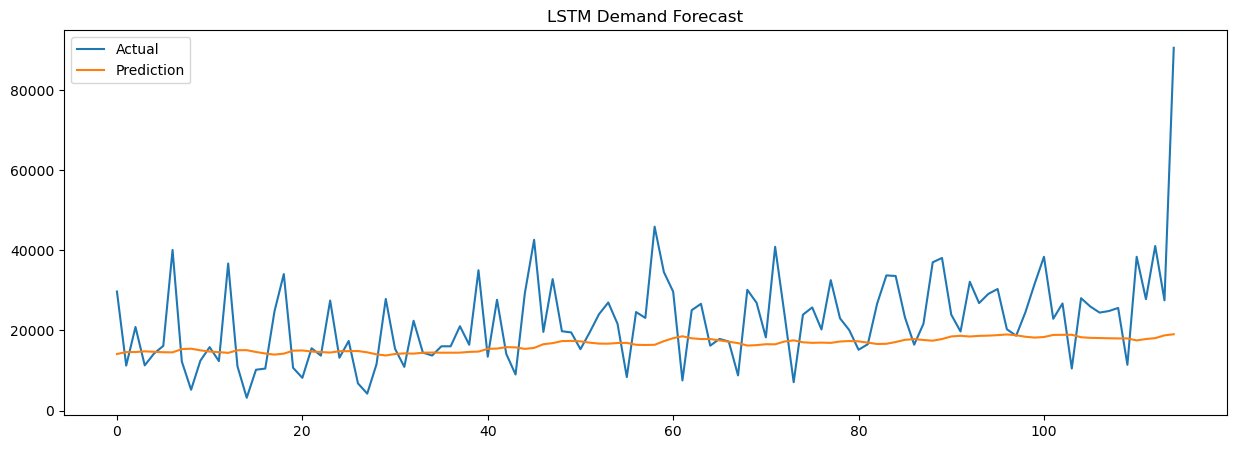

In [15]:
plt.figure(figsize=(15,5))

plt.plot(actual, label="Actual")

plt.plot(predictions, label="Prediction")

plt.legend()

plt.title("LSTM Demand Forecast")

plt.show()

In [16]:
torch.save(model.state_dict(), "lstm_demand_model.pth")

print("Model saved successfully.")

Model saved successfully.
